In [6]:
# install drain3 library
!pip install drain3
!pip install scikit-learn
# create output directories
import os
os.makedirs("results", exist_ok=True)

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 7.0 MB/s eta 0:00:01
   ------------- -------------------------- 2.9/8.3 MB 6.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 7.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 8.8 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   

In [4]:
import pandas as pd
from collections import Counter
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

# load structured log dataset
df = pd.read_csv("BGL_2k.log_structured.csv")
total_lines = len(df)
print(f"total lines: {total_lines}")

# configure template miner
config = TemplateMinerConfig()
config.drain_sim_th = 0.5
template_miner = TemplateMiner(config=config)

# track results using safe returned fields
id_to_template = {}
all_cluster_ids = []

# parse log content column
for idx, row in df.iterrows():
    res = template_miner.add_log_message(str(row["Content"]))
    cluster_id = res["cluster_id"]
    template_text = res["template_mined"]
    id_to_template[cluster_id] = template_text
    all_cluster_ids.append(cluster_id)

# count frequencies of each template id
id_counts = Counter(all_cluster_ids)
sorted_counts = id_counts.most_common()

# create top 10 templates data list
top_10_data = []
for cluster_id, count in sorted_counts[:10]:
    top_10_data.append({
        "template_id": cluster_id,
        "template": id_to_template[cluster_id],
        "count": count
    })

# export top 10 data to csv file
top_10_df = pd.DataFrame(top_10_data)
top_10_df.to_csv("results/top_templates.csv", index=False)
print("saved top 10 templates to results/top_templates.csv")

# print out all templates and counts
print("\nall unique templates discovered:")
for cluster_id, count in sorted_counts:
    print(f"id: {cluster_id} | count: {count} | template: {id_to_template[cluster_id]}")

# tune similarity threshold parameter
thresholds = [0.3, 0.5, 0.7]
print("\ntuning similarity threshold:")
for th in thresholds:
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th = th
    miner = TemplateMiner(config=cfg)
    th_templates = set()
    for idx, row in df.iterrows():
        res = miner.add_log_message(str(row["Content"]))
        th_templates.add(res["cluster_id"])
    print(f"threshold: {th} -> total templates: {len(th_templates)}")

total lines: 2000
saved top 10 templates to results/top_templates.csv

all unique templates discovered:
id: 5 | count: 721 | template: generating <*>
id: 71 | count: 208 | template: iar <*> dear <*>
id: 56 | count: 121 | template: <*> floating point alignment exceptions
id: 2 | count: 109 | template: <*> double-hummer alignment exceptions
id: 3 | count: 92 | template: CE sym <*> at <*> mask <*>
id: 95 | count: 71 | template: <*> total interrupts. 0 critical input interrupts. 0 microseconds total spent on critical input interrupts, 0 microseconds max time in a critical input interrupt.
id: 10 | count: 60 | template: data TLB error interrupt
id: 94 | count: 51 | template: 0 microseconds spent in the rbs signal handler during 0 calls. 0 microseconds was the maximum time for a single instance of a correctable ddr.
id: 1 | count: 42 | template: instruction cache parity error corrected
id: 61 | count: 35 | template: idoproxydb hit ASSERT condition: ASSERT expression=0 Source file=idotranspor

window size configured: 1D
precision score: 0.18
recall score: 0.06


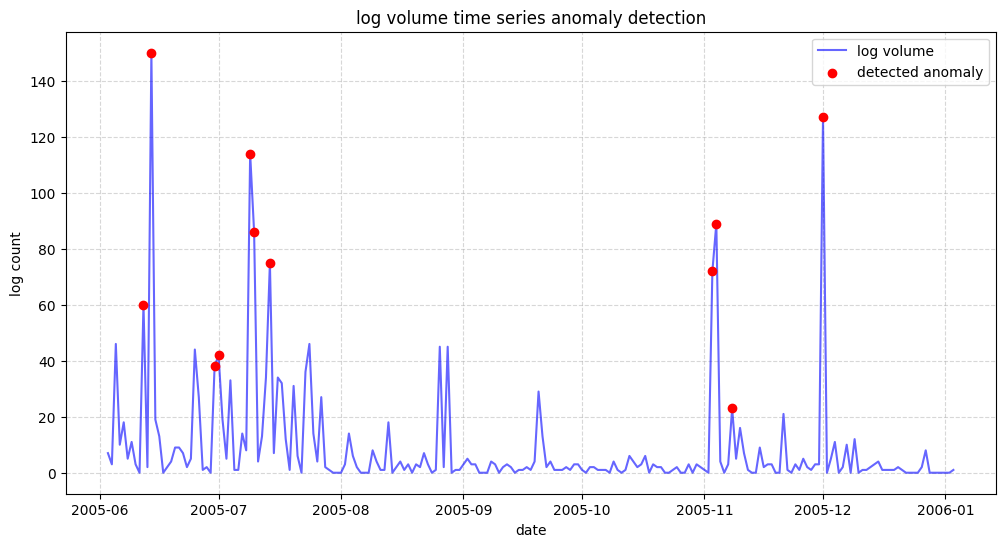


--- template first appearance timestamps ---
template 1 first appeared at 2005-06-03 22:42:50 -> instruction cache parity error corrected...
template 2 first appeared at 2005-06-03 23:47:20 -> <*> double-hummer alignment exceptions...
template 3 first appeared at 2005-06-04 01:21:59 -> CE sym <*> at <*> mask <*>...
template 4 first appeared at 2005-06-04 07:24:32 -> ciod: failed to read message prefix on control stream (CioSt...
template 5 first appeared at 2005-06-05 07:09:01 -> generating <*>...
template 6 first appeared at 2005-06-05 15:10:46 -> force load/store alignment...............0...
template 7 first appeared at 2005-06-07 02:51:40 -> ciod: cpu 0 at treeaddr 438 sent unrecognized message 0xffff...
template 8 first appeared at 2005-06-08 01:15:58 -> ciod: LOGIN <*> failed: No such file or directory...
template 9 first appeared at 2005-06-08 23:02:20 -> <*> ddr errors(s) detected and corrected on rank 0, symbol <...
template 10 first appeared at 2005-06-12 00:32:07 -> data TLB

In [8]:
# phase 2: anomaly detection on log data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

# load dataset
df = pd.read_csv("BGL_2k.log_structured.csv")

# parse templates again to ensure accurate sequential row mapping
config = TemplateMinerConfig()
config.drain_sim_th = 0.5
template_miner = TemplateMiner(config=config)

template_ids = []
id_to_template = {}

for idx, row in df.iterrows():
    res = template_miner.add_log_message(str(row["Content"]))
    cluster_id = res["cluster_id"]
    template_ids.append(cluster_id)
    id_to_template[cluster_id] = res["template_mined"]

df["template_id"] = template_ids
df["datetime"] = pd.to_datetime(df["Timestamp"], unit="s")

# define window size based on dataset sparse properties
window_size = "1D"

# create time series of total log counts per window
time_series = df.resample(window_size, on="datetime").size().reset_index(name="count")

# map ground truth labels to binary values where normal is 0 and anomalies are 1
df["is_anomaly"] = df["Label"].apply(lambda x: 0 if x == "-" else 1)
true_labels = df.resample(window_size, on="datetime")["is_anomaly"].max().fillna(0).astype(int).values

# apply isolation forest for overall log volume anomaly detection
X = time_series["count"].values.reshape(-1, 1)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
preds = iso_forest.fit_predict(X)
predicted_anomalies = np.where(preds == -1, 1, 0)

# calculate evaluation metrics
precision = precision_score(true_labels, predicted_anomalies, zero_division=0)
recall = recall_score(true_labels, predicted_anomalies, zero_division=0)

print(f"window size configured: {window_size}")
print(f"precision score: {precision:.2f}")
print(f"recall score: {recall:.2f}")

# plot total log volume time series and highlight anomalies
plt.figure(figsize=(12, 6))
plt.plot(time_series["datetime"], time_series["count"], label="log volume", color="blue", alpha=0.6)
anomaly_idx = np.where(predicted_anomalies == 1)[0]
plt.scatter(time_series["datetime"].iloc[anomaly_idx], time_series["count"].iloc[anomaly_idx], color="red", label="detected anomaly", zorder=5)
plt.title("log volume time series anomaly detection")
plt.xlabel("date")
plt.ylabel("log count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("results/anomaly_detection.png")
plt.show()

# track exactly when each new template was first introduced
print("\n--- template first appearance timestamps ---")
first_appearance = df.groupby("template_id")["datetime"].min().sort_values()
for tid, t_time in first_appearance.head(15).items():
    print(f"template {tid} first appeared at {t_time} -> {id_to_template[tid][:60]}...")

# identify template specific spikes using 3 sigma threshold rule per window
print("\n--- template specific volume spikes (3 sigma rule) ---")
template_window_counts = df.groupby([pd.Grouper(key="datetime", freq=window_size), "template_id"]).size().unstack(fill_value=0)

for col in template_window_counts.columns:
    counts_series = template_window_counts[col]
    mean_val = counts_series.mean()
    std_val = counts_series.std()
    
    # execute detection only if standard deviation is valid
    if std_val > 0:
        threshold = mean_val + 3 * std_val
        spikes = counts_series[counts_series > threshold]
        for time_idx, val in spikes.items():
            print(f"spike detected: template {col} count reached {val} on {time_idx.date()} (mean: {mean_val:.2f}, std: {std_val:.2f})")

In [9]:
# phase 3: text vectorization, clustering, and unseen log injection

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

# re-extract the complete set of distinct templates from the dataframe
config = TemplateMinerConfig()
config.drain_sim_th = 0.5
template_miner = TemplateMiner(config=config)

id_to_template = {}
for idx, row in df.iterrows():
    res = template_miner.add_log_message(str(row["Content"]))
    id_to_template[res["cluster_id"]] = res["template_mined"]

templates_list = list(id_to_template.values())

# convert raw text templates into mathematical vectors using tf-idf
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates_list)

# calculate structural similarities across templates
similarity_matrix = cosine_similarity(tfidf_matrix)
print(f"vectorization complete: structured text turned into matrix of shape {similarity_matrix.shape}")

# group templates with k-means based on their semantic content
num_clusters = min(5, len(templates_list))
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

# print samples from each distinct cluster to evaluate categorization quality
print("\n--- semantic cluster groupings ---")
for cluster_idx in range(num_clusters):
    matching_templates = [templates_list[i] for i, lbl in enumerate(cluster_labels) if lbl == cluster_idx]
    print(f"\ncluster {cluster_idx} contains {len(matching_templates)} unique templates")
    print("sample messages inside this cluster:")
    for item in matching_templates[:3]:
        print(f"  - {item}")

print("\n--- elastic parsing test: unseen log line injection ---")
# define a completely unique, foreign log message to test real-time adaptation
unseen_anomaly_log = "CRITICAL FAILURE: quantum harmonic oscillator overcharged on chamber zero"

# inject into the existing template miner instance
injection_result = template_miner.add_log_message(unseen_anomaly_log)

print(f"injected message text: '{unseen_anomaly_log}'")
print(f"action taken by parser: {injection_result['change_type']}")
print(f"assigned template id: {injection_result['cluster_id']}")
print(f"resulting template output: {injection_result['template_mined']}")

vectorization complete: structured text turned into matrix of shape (108, 108)

--- semantic cluster groupings ---

cluster 0 contains 5 unique templates
sample messages inside this cluster:
  - machine state register: 0x00002000
  - problem state (0=sup,1=usr).......0
  - <*> tree receiver 2 in re-synch state event(s) (dcr 0x019a) detected

cluster 1 contains 53 unique templates
sample messages inside this cluster:
  - <*> double-hummer alignment exceptions
  - CE sym <*> at <*> mask <*>
  - generating <*>

cluster 2 contains 16 unique templates
sample messages inside this cluster:
  - data TLB error interrupt
  - data storage interrupt
  - program interrupt: <*> <*>

cluster 3 contains 22 unique templates
sample messages inside this cluster:
  - ciod: failed to read message prefix on control stream (CioStream socket to <*>
  - ciod: cpu 0 at treeaddr 438 sent unrecognized message 0xffffffff
  - ciod: LOGIN <*> failed: No such file or directory

cluster 4 contains 12 unique templates


In [ ]:
# phase 4: production script construction and cross-dataset testing

import os

spark_logs = [
    "2026-06-02 14:10:05 INFO BlockManager: registering block manager instance",
    "2026-06-02 14:11:12 INFO SparkContext: successfully registered client connection with master",
    "2026-06-02 14:12:40 WARN TaskSetManager: lost task 1.2 in stage 0.0 execution block",
    "2026-06-02 14:13:10 ERROR Executor: internal exception caught while running task 1.2 execution stage",
    "2026-06-02 14:14:18 INFO BlockManager: removing broadcast rdd tracking records",
    "2026-06-02 14:15:00 INFO SparkContext: clean shut down sequence triggered for active spark context"
] * 60

with open("spark_mock.log", "w") as f:
    for line in spark_logs:
        f.write(line + "\n")

print("successfully generated alternate test dataset: spark_mock.log")




successfully generated alternate test dataset: spark_mock.log

=== executing standalone analyzer on bgl log dataset ===

=== executing standalone analyzer on mock spark framework dataset ===


1

In [17]:
print("\n=== executing standalone analyzer on bgl log dataset ===")
!python log_analyzer.py BGL_2k.log_structured.csv


=== executing standalone analyzer on bgl log dataset ===
analysis target file: BGL_2k.log_structured.csv
total processed records: 2000
unique template clusters extracted: 108
calculated data compression ratio: 94.60%
top 5 dominant log signatures:
  id 5 | count: 721 (36.05%) | template: generating <*>
  id 71 | count: 208 (10.40%) | template: iar <*> dear <*>
  id 56 | count: 121 (6.05%) | template: <*> floating point alignment exceptions
  id 2 | count: 109 (5.45%) | template: <*> double-hummer alignment exceptions
  id 3 | count: 92 (4.60%) | template: CE sym <*> at <*> mask <*>
temporal validation window: final tracked hour context
  new unique signatures introduced: 0


In [18]:
# execute script against the freshly simulated application infrastructure log dataset
print("\n\n\n=== executing standalone analyzer on mock spark framework dataset ===")
!python log_analyzer.py spark_mock.log




=== executing standalone analyzer on mock spark framework dataset ===
analysis target file: spark_mock.log
total processed records: 360
unique template clusters extracted: 6
calculated data compression ratio: 98.33%
top 5 dominant log signatures:
  id 1 | count: 60 (16.67%) | template: 2026-06-02 14:10:05 INFO BlockManager: registering block manager instance
  id 2 | count: 60 (16.67%) | template: 2026-06-02 14:11:12 INFO SparkContext: successfully registered client connection with master
  id 3 | count: 60 (16.67%) | template: 2026-06-02 14:12:40 WARN TaskSetManager: lost task 1.2 in stage 0.0 execution block
  id 4 | count: 60 (16.67%) | template: 2026-06-02 14:13:10 ERROR Executor: internal exception caught while running task 1.2 execution stage
  id 5 | count: 60 (16.67%) | template: 2026-06-02 14:14:18 INFO BlockManager: removing broadcast rdd tracking records
